## Looking to see how minutes change during certain situations

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
s22 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s22, s23, s24, s25, s26])
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)

Number of rows: 131291
Number of columns: 189


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread
24676,2024-25,1630241,Sam Merrill,Sam,1610612739,CLE,Cleveland Cavaliers,0022400133,2024-11-01T00:00:00,CLE vs. ORL,...,104.7,101.50,84.58,101,0.444,Regular Season,SG,216.0,-7.0,-7.0
17074,2021-22,1629661,Cameron Johnson,Cameron,1610612756,PHX,Phoenix Suns,0022100416,2021-12-14T00:00:00,PHX @ POR,...,96.6,95.09,79.25,105,0.451,Regular Season,PF,216.5,1.0,-1.0
1559,2022-23,1627783,Pascal Siakam,Pascal,1610612761,TOR,Toronto Raptors,0022201150,2023-03-31T00:00:00,TOR @ PHI,...,93.1,90.00,75.00,90,0.558,Regular Season,PF,223.5,-4.0,4.0
15539,2024-25,1629629,Cam Reddish,Cam,1610612747,LAL,Los Angeles Lakers,0022400477,2025-01-03T00:00:00,LAL vs. ATL,...,102.0,99.00,82.50,100,0.402,Regular Season,SF,235.0,-2.5,-2.5
24857,2024-25,1630191,Isaiah Stewart,Isaiah,1610612765,DET,Detroit Pistons,0022400120,2024-10-30T00:00:00,DET @ PHI,...,92.5,92.00,76.67,92,0.442,Regular Season,C,219.5,-4.0,4.0


In [43]:
# Helpers
starter = df["start_position"].astype("string").str.strip()
df["starting"] = starter.isin(["G", "F", "C"]).astype(int)
df["starting"].value_counts(dropna=False)

starting
0    69791
1    61500
Name: count, dtype: int64

In [44]:
starting = df[df["starting"] == 1]
bench = df[df["starting"] == 0]
pd.concat(
    {
        "starting": starting["minutes"].describe(),
        "bench": bench["minutes"].describe(),
    },
    axis=1,
)


,starting,bench
count,61500.000000,69791.000000
mean,30.532756,15.642483
std,6.723093,8.611857
min,0.066667,0.000000
25%,26.416667,8.583333
50%,31.350000,16.033333
75%,35.366667,21.988333
max,56.516667,47.216667


### First we will look at starters

In [45]:
starter_minutes_by_slot = starting.groupby(
    starting["start_position"].astype("string").str.strip(),
    dropna=False,
)["minutes"].describe().T
starter_minutes_by_pos = starting.groupby("pos", dropna=False)["minutes"].describe().T

starter_minutes_by_slot = starter_minutes_by_slot.reindex(
    columns=["G", "F", "C"],
)
starter_minutes_by_pos = starter_minutes_by_pos.reindex(
    columns=["PG", "SG", "SF", "PF", "C"],
)

display(starter_minutes_by_slot)
display(starter_minutes_by_pos)

start_position,G,F,C
count,24600.000000,24600.000000,12300.000000
mean,31.607446,30.597826,28.253236
std,6.383822,6.697252,6.876023
min,0.066667,0.100000,0.366667
25%,27.842917,26.483333,23.916667
50%,32.381667,31.445000,28.883333
75%,36.133333,35.400000,33.189583
max,55.650000,56.333333,56.516667


pos,PG,SG,SF,PF,C
count,11477.000000,13579.000000,11998.000000,12004.000000,12434.000000
mean,31.955774,30.964139,30.875097,30.584026,28.369485
std,6.251637,6.570545,6.730006,6.680597,6.832134
min,0.133333,0.066667,0.100000,0.116667,0.366667
25%,28.316667,26.966667,26.833333,26.583333,24.050000
50%,32.750000,31.753333,31.728333,31.495000,29.040000
75%,36.333333,35.686667,35.690833,35.383333,33.300000
max,53.950000,55.650000,55.816667,56.516667,52.633333


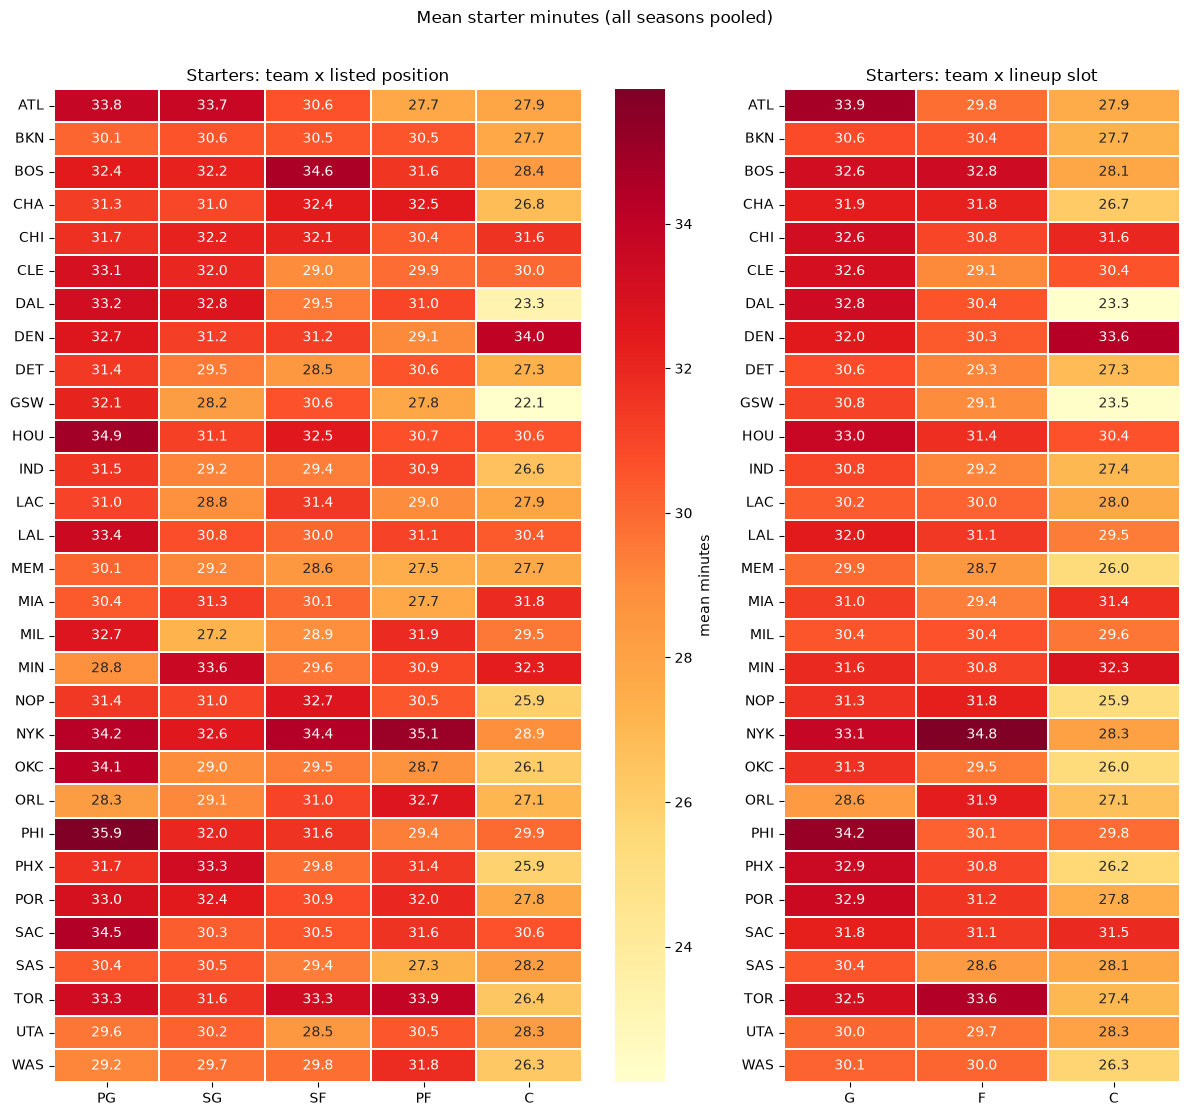

In [46]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
slot_order = ["G", "F", "C"]

starter_pos = starting.assign(
    pos=starting["pos"].astype("string"),
    start_slot=starting["start_position"].astype("string").str.strip(),
)

minutes_by_team_pos = (
    starter_pos.loc[starter_pos["pos"].isin(pos_order)]
    .groupby(["team_abbreviation", "pos"], observed=False)["minutes"]
    .mean()
    .unstack("pos")
    .reindex(columns=pos_order)
    .sort_index()
)
minutes_by_team_slot = (
    starter_pos.loc[starter_pos["start_slot"].isin(slot_order)]
    .groupby(["team_abbreviation", "start_slot"], observed=False)["minutes"]
    .mean()
    .unstack("start_slot")
    .reindex(columns=slot_order)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 11), gridspec_kw={"width_ratios": [5, 3]})
sns.heatmap(
    minutes_by_team_pos,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "mean minutes"},
)
axes[0].set_title("Starters: team x listed position")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    minutes_by_team_slot,
    ax=axes[1],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar=False,
)
axes[1].set_title("Starters: team x lineup slot")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Mean starter minutes (all seasons pooled)", y=1.01)
plt.tight_layout()
plt.show()

inference:
- PG: PHI @ 35.9
- SG: ATL @ 33.7
- SF: BOS @ 34.6
- PF: NYK @ 35.1
- C: DEN @ 34.0

spread_role,≤ -7.5,-7.5 to -3,-3 to 3.5,> 3.5
pos,,,,
PG,31.75,32.74,32.41,31.18
SG,30.39,31.27,31.51,30.71
SF,30.31,31.19,31.00,30.94
PF,30.12,30.81,31.05,30.34
C,28.47,28.96,28.53,27.87


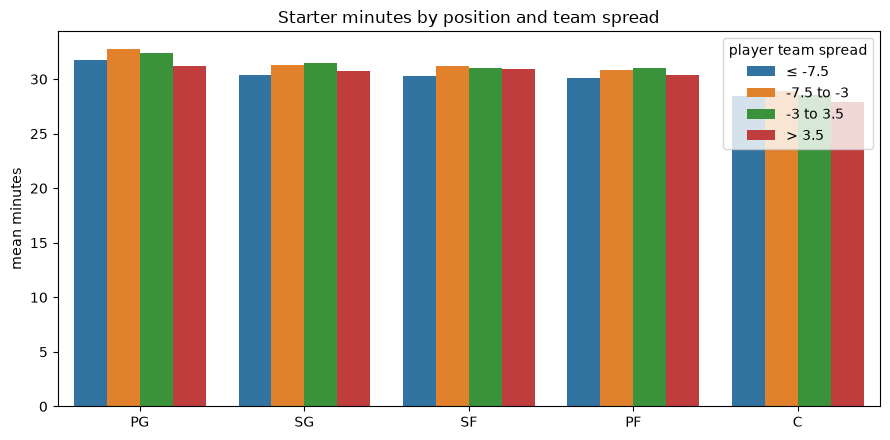

In [47]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
spread_order = ["≤ -7.5", "-7.5 to -3", "-3 to 3.5", "> 3.5"]
spread = pd.to_numeric(starting["player_team_spread"], errors="coerce")
starter_script = starting.assign(
    pos=starting["pos"].astype("string"),
    spread_role=pd.cut(
        spread,
        bins=[-np.inf, -7.5, -3, 3.5, np.inf],
        labels=spread_order,
        right=True,
    ).astype("string"),
)
starter_script = starter_script.loc[
    starter_script["pos"].isin(pos_order)
    & starter_script["spread_role"].isin(spread_order)
]

minutes_by_pos_script = (
    starter_script.groupby(["pos", "spread_role"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    minutes_by_pos_script.pivot(index="pos", columns="spread_role", values="mean")
    .reindex(index=pos_order, columns=spread_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=minutes_by_pos_script,
    x="pos",
    y="mean",
    hue="spread_role",
    order=pos_order,
    hue_order=spread_order,
    ax=ax,
)
ax.set_title("Starter minutes by position and team spread")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="player team spread")
plt.tight_layout()
plt.show()


total_band,≤ 221,221–227,227.5–233.5,≥ 234
pos,,,,
PG,31.88,32.04,31.84,32.04
SG,31.39,31.06,30.79,30.64
SF,31.37,31.19,30.77,30.16
PF,31.00,30.69,30.12,30.49
C,28.49,28.37,28.18,28.49


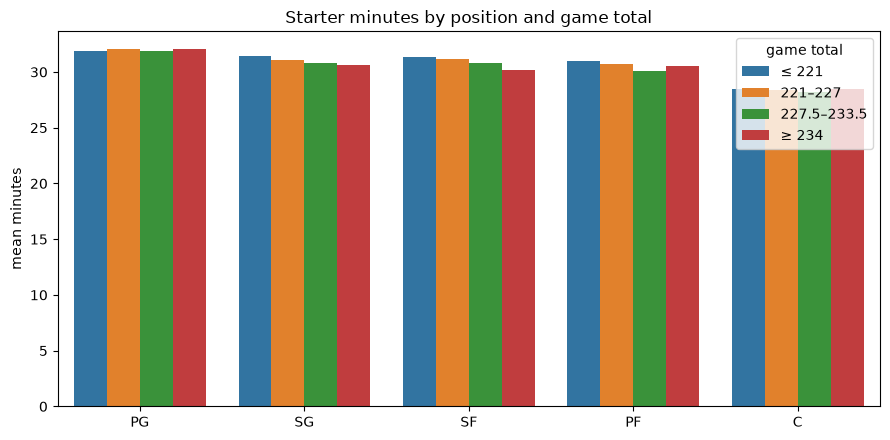

In [48]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
total_order = ["≤ 221", "221–227", "227.5–233.5", "≥ 234"]
game_total = pd.to_numeric(starting["game_total"], errors="coerce")
starter_total = starting.assign(
    pos=starting["pos"].astype("string"),
    total_band=pd.cut(
        game_total,
        bins=[-np.inf, 221, 227, 233.5, np.inf],
        labels=total_order,
        right=True,
    ).astype("string"),
)
starter_total = starter_total.loc[
    starter_total["pos"].isin(pos_order)
    & starter_total["total_band"].isin(total_order)
]

minutes_by_pos_total = (
    starter_total.groupby(["pos", "total_band"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    minutes_by_pos_total.pivot(index="pos", columns="total_band", values="mean")
    .reindex(index=pos_order, columns=total_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=minutes_by_pos_total,
    x="pos",
    y="mean",
    hue="total_band",
    order=pos_order,
    hue_order=total_order,
    ax=ax,
)
ax.set_title("Starter minutes by position and game total")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="game total")
plt.tight_layout()
plt.show()


rest_band,B2B,2,3,3+
pos,,,,
PG,32.00,32.04,32.05,31.30
SG,30.92,31.10,30.91,30.32
SF,30.93,30.99,30.83,30.16
PF,30.48,30.68,30.72,29.96
C,28.19,28.54,28.43,27.65


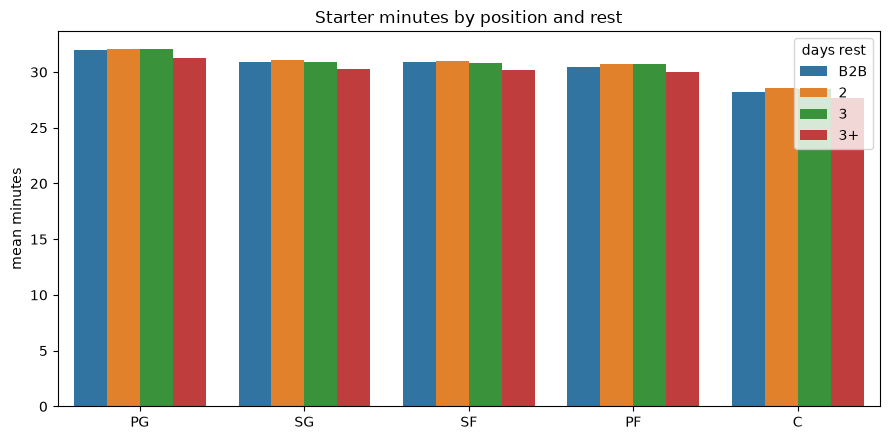

In [49]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
rest_order = ["B2B", "2", "3", "3+"]

rest = df.copy()
rest["game_date"] = pd.to_datetime(rest["game_date"])
rest = rest.sort_values(["player_id", "season_year", "game_date"], kind="stable")
rest["days_rest"] = (
    rest.groupby(["player_id", "season_year"], sort=False)["game_date"]
    .diff()
    .dt.days
)
rest["rest_band"] = np.select(
    [
        rest["days_rest"].eq(1),
        rest["days_rest"].eq(2),
        rest["days_rest"].eq(3),
        rest["days_rest"].ge(4),
    ],
    rest_order,
    default="other",
)

starter_rest = rest.loc[rest["starting"].eq(1)].assign(
    pos=lambda frame: frame["pos"].astype("string"),
)
starter_rest = starter_rest.loc[
    starter_rest["pos"].isin(pos_order)
    & starter_rest["rest_band"].isin(rest_order)
]

minutes_by_pos_rest = (
    starter_rest.groupby(["pos", "rest_band"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    minutes_by_pos_rest.pivot(index="pos", columns="rest_band", values="mean")
    .reindex(index=pos_order, columns=rest_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=minutes_by_pos_rest,
    x="pos",
    y="mean",
    hue="rest_band",
    order=pos_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Starter minutes by position and rest")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()

rest_band,B2B,2,3,3+
season_year,,,,
2021-22,30.63,30.72,30.45,29.86
2022-23,30.79,31.09,31.13,30.30
2023-24,30.70,31.06,30.73,30.44
2024-25,30.75,30.53,30.62,30.00
2025-26,29.62,29.86,29.87,28.67


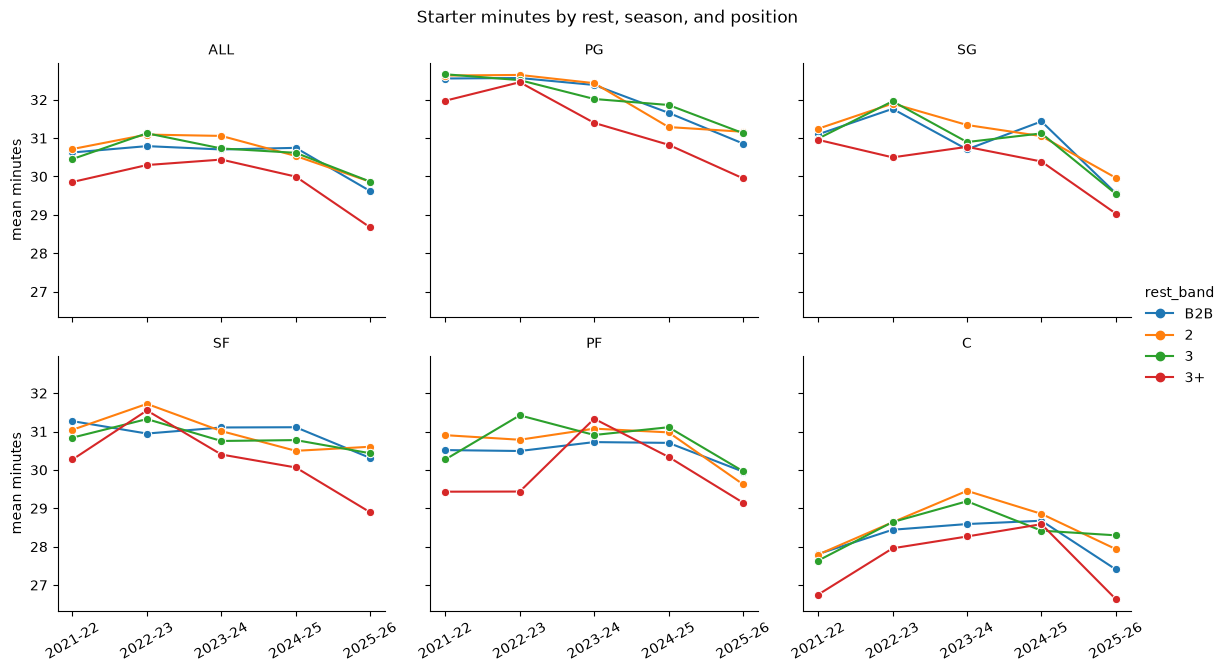

In [50]:
season_order = ["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
starter_rest_year = starter_rest.assign(
    season_year=starter_rest["season_year"].astype("string"),
)
starter_rest_year = starter_rest_year.loc[
    starter_rest_year["season_year"].isin(season_order)
]

minutes_by_year_rest = (
    starter_rest_year.groupby(
        ["season_year", "pos", "rest_band"],
        observed=False,
    )["minutes"]
    .mean()
    .reset_index(name="mean")
)
overall_by_year_rest = (
    starter_rest_year.groupby(["season_year", "rest_band"], observed=False)["minutes"]
    .mean()
    .reset_index(name="mean")
    .assign(pos="ALL")
)
means = (
    overall_by_year_rest.pivot(index="season_year", columns="rest_band", values="mean")
    .reindex(index=season_order, columns=rest_order)
)
display(means.round(2))

plot = pd.concat([overall_by_year_rest, minutes_by_year_rest], ignore_index=True)
figure = sns.relplot(
    data=plot,
    x="season_year",
    y="mean",
    hue="rest_band",
    hue_order=rest_order,
    col="pos",
    col_order=["ALL", *pos_order],
    col_wrap=3,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.2,
)
figure.set_axis_labels("", "mean minutes")
figure.set_titles("{col_name}")
figure.figure.suptitle(
    "Starter minutes by rest, season, and position",
    y=1.03,
)
for ax in figure.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
plt.show()


season_phase,before All-Star,after All-Star
pos,,
PG,32.11,31.66
SG,30.94,31.04
SF,30.89,30.87
PF,30.78,30.16
C,28.48,28.17


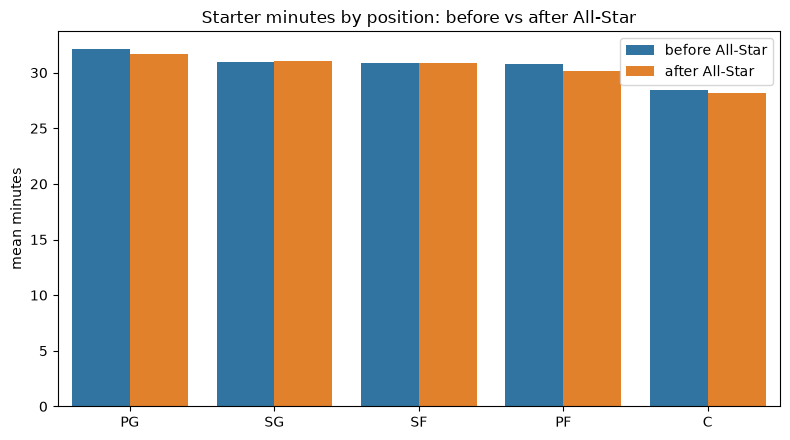

season_phase,before All-Star,after All-Star
rest_band,,
B2B,30.56,30.36
2,30.72,30.53
3,30.61,30.43
3+,30.03,29.47


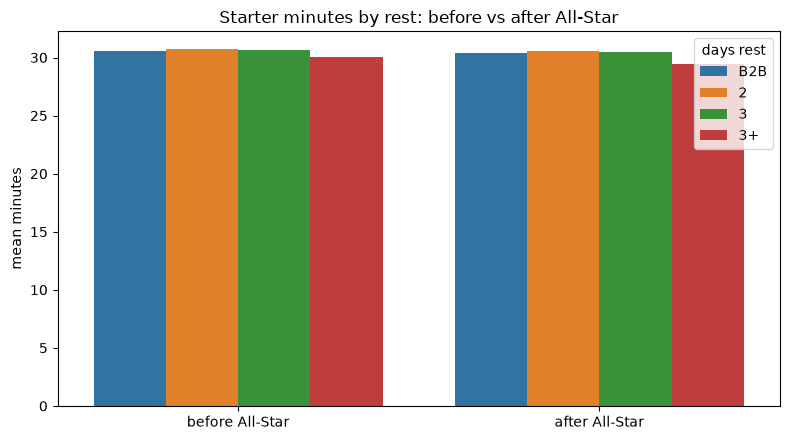

In [51]:
phase_order = ["before All-Star", "after All-Star"]
ALL_STAR_DATES = {
    "2021-22": pd.Timestamp("2022-02-20"),
    "2022-23": pd.Timestamp("2023-02-19"),
    "2023-24": pd.Timestamp("2024-02-18"),
    "2024-25": pd.Timestamp("2025-02-16"),
    "2025-26": pd.Timestamp("2026-02-15"),
}
game_date = pd.to_datetime(starter_rest["game_date"])
asb = starter_rest["season_year"].map(ALL_STAR_DATES)
starter_phase = starter_rest.assign(
    season_phase=np.select(
        [game_date.lt(asb), game_date.gt(asb)],
        phase_order,
        default="other",
    ),
)
starter_phase = starter_phase.loc[
    starter_phase["season_phase"].isin(phase_order)
]

minutes_by_pos_phase = (
    starter_phase.groupby(["pos", "season_phase"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means_phase = (
    minutes_by_pos_phase.pivot(index="pos", columns="season_phase", values="mean")
    .reindex(index=pos_order, columns=phase_order)
)
display(means_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=minutes_by_pos_phase,
    x="pos",
    y="mean",
    hue="season_phase",
    order=pos_order,
    hue_order=phase_order,
    ax=ax,
)
ax.set_title("Starter minutes by position: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="")
plt.tight_layout()
plt.show()

minutes_by_rest_phase = (
    starter_phase.groupby(["rest_band", "season_phase"], observed=False)["minutes"]
    .mean()
    .reset_index(name="mean")
)
means_rest_phase = (
    minutes_by_rest_phase.pivot(index="rest_band", columns="season_phase", values="mean")
    .reindex(index=rest_order, columns=phase_order)
)
display(means_rest_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=minutes_by_rest_phase,
    x="season_phase",
    y="mean",
    hue="rest_band",
    order=phase_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Starter minutes by rest: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()


### Now we'll explore bench players

In [52]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_minutes_by_pos = (
    bench.groupby("pos", dropna=False)["minutes"]
    .describe()
    .T
    .reindex(columns=pos_order)
)
display(bench_minutes_by_pos)


pos,PG,SG,SF,PF,C
count,11394.000000,19269.000000,13196.000000,12933.000000,12798.000000
mean,16.119914,16.640514,15.744679,15.510551,13.730093
std,8.480239,9.021057,9.094332,8.342859,7.493861
min,0.018333,0.000000,0.008333,0.000000,0.000000
25%,9.800000,9.200000,7.556250,8.800000,7.600000
50%,16.450000,17.416667,16.233333,16.016667,13.983333
75%,22.267917,23.461667,22.723333,21.716667,18.970417
max,47.216667,46.700000,45.750000,46.583333,42.850000


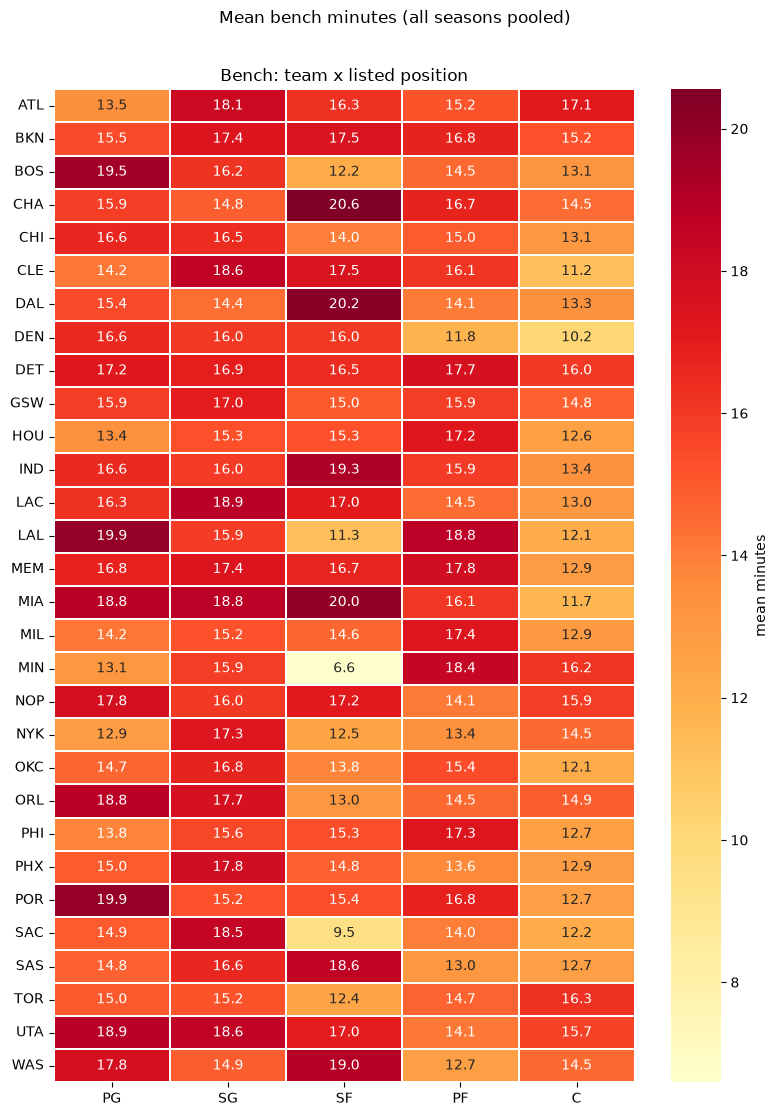

In [53]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_pos = bench.assign(pos=bench["pos"].astype("string"))
minutes_by_team_pos = (
    bench_pos.loc[bench_pos["pos"].isin(pos_order)]
    .groupby(["team_abbreviation", "pos"], observed=False)["minutes"]
    .mean()
    .unstack("pos")
    .reindex(columns=pos_order)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(
    minutes_by_team_pos,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "mean minutes"},
)
ax.set_title("Bench: team x listed position")
ax.set_xlabel("")
ax.set_ylabel("")
fig.suptitle("Mean bench minutes (all seasons pooled)", y=1.01)
plt.tight_layout()
plt.show()


spread_role,≤ -7.5,-7.5 to -3,-3 to 3.5,> 3.5
pos,,,,
PG,14.88,15.63,15.79,17.36
SG,15.90,16.69,16.69,17.01
SF,14.45,15.30,15.59,16.85
PF,14.82,15.36,15.35,16.16
C,13.07,13.23,13.71,14.45


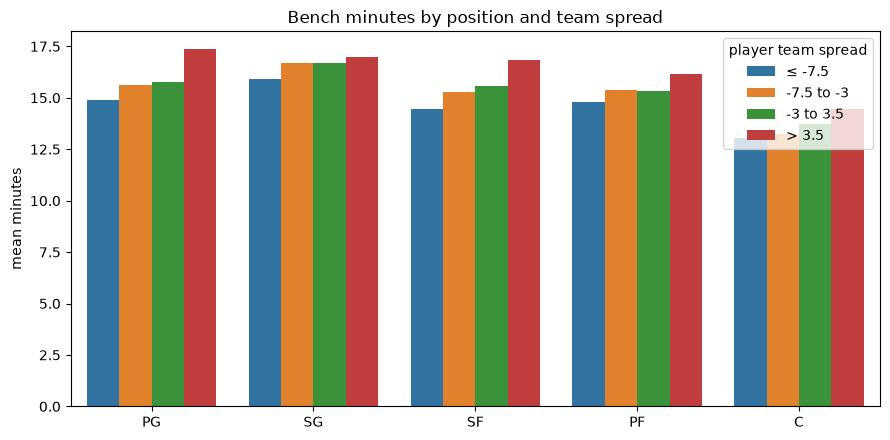

In [54]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
spread_order = ["≤ -7.5", "-7.5 to -3", "-3 to 3.5", "> 3.5"]
spread = pd.to_numeric(bench["player_team_spread"], errors="coerce")
bench_script = bench.assign(
    pos=bench["pos"].astype("string"),
    spread_role=pd.cut(
        spread,
        bins=[-np.inf, -7.5, -3, 3.5, np.inf],
        labels=spread_order,
        right=True,
    ).astype("string"),
)
bench_script = bench_script.loc[
    bench_script["pos"].isin(pos_order)
    & bench_script["spread_role"].isin(spread_order)
]

minutes_by_pos_script = (
    bench_script.groupby(["pos", "spread_role"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    minutes_by_pos_script.pivot(index="pos", columns="spread_role", values="mean")
    .reindex(index=pos_order, columns=spread_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=minutes_by_pos_script,
    x="pos",
    y="mean",
    hue="spread_role",
    order=pos_order,
    hue_order=spread_order,
    ax=ax,
)
ax.set_title("Bench minutes by position and team spread")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="player team spread")
plt.tight_layout()
plt.show()


total_band,≤ 221,221–227,227.5–233.5,≥ 234
pos,,,,
PG,15.97,15.99,16.31,16.14
SG,16.75,16.60,16.65,16.52
SF,15.47,15.72,15.52,16.34
PF,15.96,15.80,15.31,14.87
C,13.70,13.71,13.69,13.83


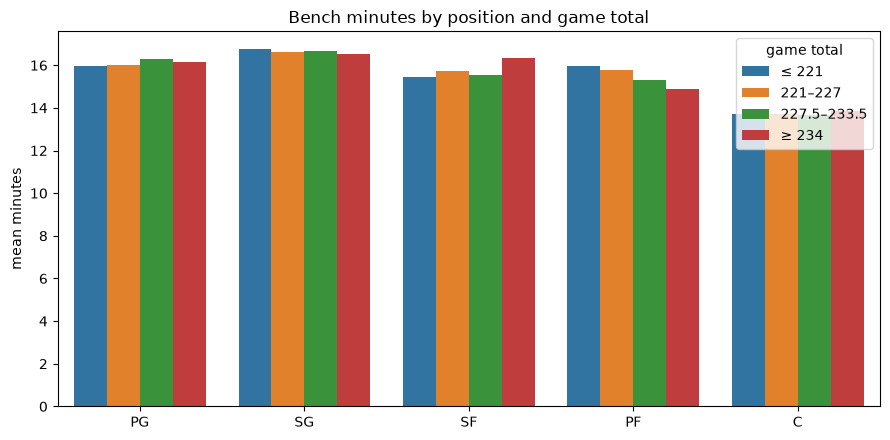

In [55]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
total_order = ["≤ 221", "221–227", "227.5–233.5", "≥ 234"]
game_total = pd.to_numeric(bench["game_total"], errors="coerce")
bench_total = bench.assign(
    pos=bench["pos"].astype("string"),
    total_band=pd.cut(
        game_total,
        bins=[-np.inf, 221, 227, 233.5, np.inf],
        labels=total_order,
        right=True,
    ).astype("string"),
)
bench_total = bench_total.loc[
    bench_total["pos"].isin(pos_order)
    & bench_total["total_band"].isin(total_order)
]

minutes_by_pos_total = (
    bench_total.groupby(["pos", "total_band"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    minutes_by_pos_total.pivot(index="pos", columns="total_band", values="mean")
    .reindex(index=pos_order, columns=total_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=minutes_by_pos_total,
    x="pos",
    y="mean",
    hue="total_band",
    order=pos_order,
    hue_order=total_order,
    ax=ax,
)
ax.set_title("Bench minutes by position and game total")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="game total")
plt.tight_layout()
plt.show()


rest_band,B2B,2,3,3+
pos,,,,
PG,17.76,17.45,16.63,11.88
SG,18.44,18.09,17.15,12.04
SF,17.68,17.36,16.60,10.70
PF,16.74,16.96,15.95,11.35
C,15.03,14.87,14.36,10.33


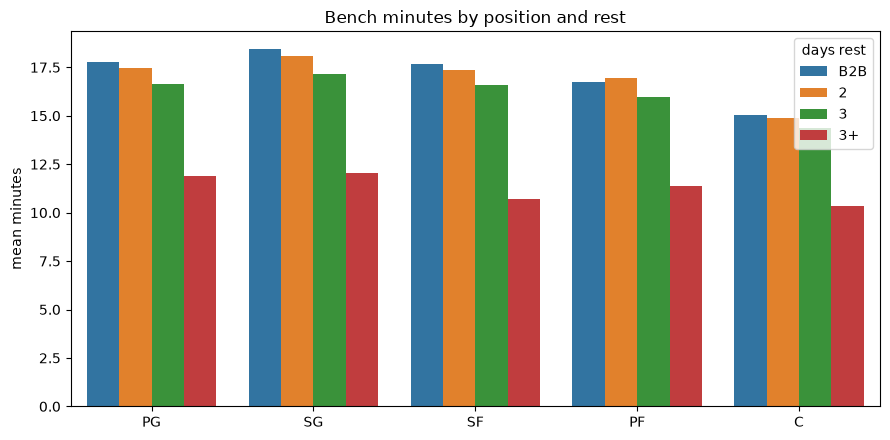

In [56]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
rest_order = ["B2B", "2", "3", "3+"]
bench_rest = rest.loc[rest["starting"].eq(0)].assign(
    pos=lambda frame: frame["pos"].astype("string"),
)
bench_rest = bench_rest.loc[
    bench_rest["pos"].isin(pos_order)
    & bench_rest["rest_band"].isin(rest_order)
]

minutes_by_pos_rest = (
    bench_rest.groupby(["pos", "rest_band"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    minutes_by_pos_rest.pivot(index="pos", columns="rest_band", values="mean")
    .reindex(index=pos_order, columns=rest_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=minutes_by_pos_rest,
    x="pos",
    y="mean",
    hue="rest_band",
    order=pos_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Bench minutes by position and rest")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()


rest_band,B2B,2,3,3+
season_year,,,,
2021-22,17.52,17.22,16.13,11.59
2022-23,17.31,17.06,16.67,11.21
2023-24,16.81,16.85,15.73,10.52
2024-25,17.03,17.19,15.91,11.36
2025-26,17.66,16.96,16.57,11.83


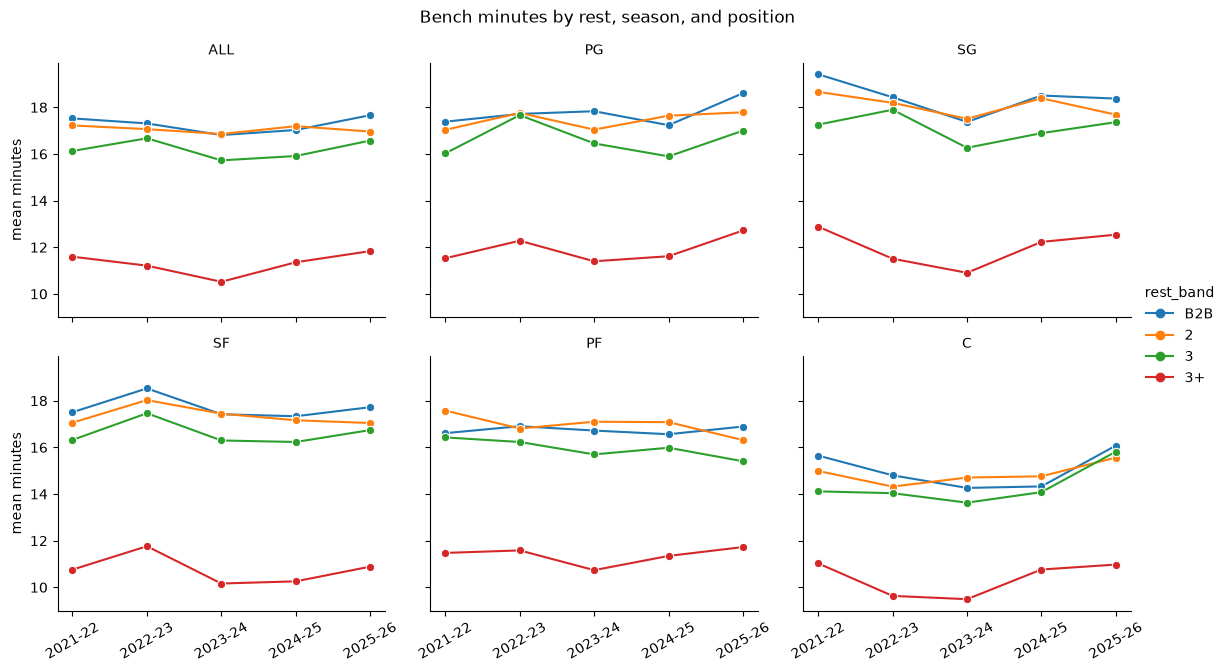

In [57]:
season_order = ["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
bench_rest_year = bench_rest.assign(
    season_year=bench_rest["season_year"].astype("string"),
)
bench_rest_year = bench_rest_year.loc[
    bench_rest_year["season_year"].isin(season_order)
]

minutes_by_year_rest = (
    bench_rest_year.groupby(
        ["season_year", "pos", "rest_band"],
        observed=False,
    )["minutes"]
    .mean()
    .reset_index(name="mean")
)
overall_by_year_rest = (
    bench_rest_year.groupby(["season_year", "rest_band"], observed=False)["minutes"]
    .mean()
    .reset_index(name="mean")
    .assign(pos="ALL")
)
means = (
    overall_by_year_rest.pivot(index="season_year", columns="rest_band", values="mean")
    .reindex(index=season_order, columns=rest_order)
)
display(means.round(2))

plot = pd.concat([overall_by_year_rest, minutes_by_year_rest], ignore_index=True)
figure = sns.relplot(
    data=plot,
    x="season_year",
    y="mean",
    hue="rest_band",
    hue_order=rest_order,
    col="pos",
    col_order=["ALL", *pos_order],
    col_wrap=3,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.2,
)
figure.set_axis_labels("", "mean minutes")
figure.set_titles("{col_name}")
figure.figure.suptitle(
    "Bench minutes by rest, season, and position",
    y=1.03,
)
for ax in figure.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
plt.show()


season_phase,before All-Star,after All-Star
pos,,
PG,15.99,16.82
SG,16.81,16.78
SF,15.90,15.85
PF,15.49,15.97
C,13.61,14.28


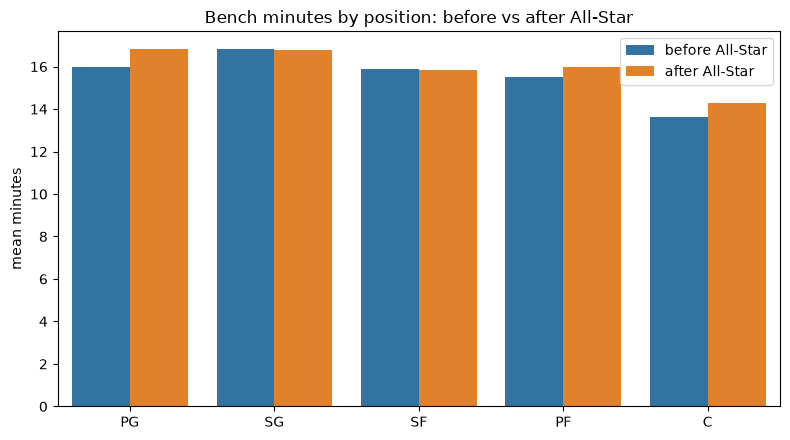

season_phase,before All-Star,after All-Star
rest_band,,
B2B,17.00,17.85
2,16.88,17.45
3,16.31,15.96
3+,11.09,11.67


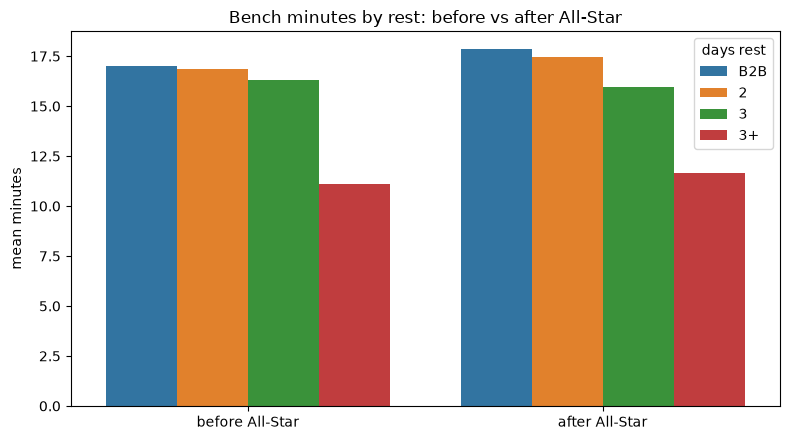

In [58]:
phase_order = ["before All-Star", "after All-Star"]
ALL_STAR_DATES = {
    "2021-22": pd.Timestamp("2022-02-20"),
    "2022-23": pd.Timestamp("2023-02-19"),
    "2023-24": pd.Timestamp("2024-02-18"),
    "2024-25": pd.Timestamp("2025-02-16"),
    "2025-26": pd.Timestamp("2026-02-15"),
}
game_date = pd.to_datetime(bench_rest["game_date"])
asb = bench_rest["season_year"].map(ALL_STAR_DATES)
bench_phase = bench_rest.assign(
    season_phase=np.select(
        [game_date.lt(asb), game_date.gt(asb)],
        phase_order,
        default="other",
    ),
)
bench_phase = bench_phase.loc[bench_phase["season_phase"].isin(phase_order)]

minutes_by_pos_phase = (
    bench_phase.groupby(["pos", "season_phase"], observed=False)["minutes"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means_phase = (
    minutes_by_pos_phase.pivot(index="pos", columns="season_phase", values="mean")
    .reindex(index=pos_order, columns=phase_order)
)
display(means_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=minutes_by_pos_phase,
    x="pos",
    y="mean",
    hue="season_phase",
    order=pos_order,
    hue_order=phase_order,
    ax=ax,
)
ax.set_title("Bench minutes by position: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="")
plt.tight_layout()
plt.show()

minutes_by_rest_phase = (
    bench_phase.groupby(["rest_band", "season_phase"], observed=False)["minutes"]
    .mean()
    .reset_index(name="mean")
)
means_rest_phase = (
    minutes_by_rest_phase.pivot(index="rest_band", columns="season_phase", values="mean")
    .reindex(index=rest_order, columns=phase_order)
)
display(means_rest_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=minutes_by_rest_phase,
    x="season_phase",
    y="mean",
    hue="rest_band",
    order=phase_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Bench minutes by rest: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean minutes")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()
